# Phase 1 – Weather and Track Context

## Objective

Analyze the weather conditions during the race session and provide contextual information for interpreting lap times and telemetry.

This analysis includes:

- Air Temperature
- Track Temperature
- Humidity
- Wind Speed
- Wind Direction
- Rainfall Status

Weather information provides context but should not be interpreted as direct evidence for changes in driver performance.

In [1]:
import fastf1
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import os
import sys
project_root=os.path.abspath("..")
sys.path.insert(0,project_root)


In [3]:
from src.data.fastf1_loader import load_session

session = load_session(
    2024,
    "British Grand Prix",
    "R",
)

core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 10)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['44', '1', '4', '81', '55', '27', '18', '14', '23', '22', '2', '20', '3', '1

In [4]:
weather = session.weather_data
weather.head()

,Time,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed
0,0 days 00:00:05.091000,15.9,67.0,991.8,False,28.1,226,2.2
1,0 days 00:01:05.070000,15.9,66.0,991.7,False,27.6,268,1.5
2,0 days 00:02:05.094000,15.9,65.0,991.7,False,27.0,291,1.4
3,0 days 00:03:05.099000,15.9,66.0,991.8,False,27.0,195,1.1
4,0 days 00:04:05.097000,15.9,64.0,991.8,False,31.0,225,1.9


In [5]:
weather.columns

Index(['Time', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp',
       'WindDirection', 'WindSpeed'],
      dtype='object')

In [6]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype          
---  ------         --------------  -----          
 0   Time           147 non-null    timedelta64[ns]
 1   AirTemp        147 non-null    float64        
 2   Humidity       147 non-null    float64        
 3   Pressure       147 non-null    float64        
 4   Rainfall       147 non-null    bool           
 5   TrackTemp      147 non-null    float64        
 6   WindDirection  147 non-null    int64          
 7   WindSpeed      147 non-null    float64        
dtypes: bool(1), float64(5), int64(1), timedelta64[ns](1)
memory usage: 8.3 KB


In [7]:
weather.describe()

,Time,AirTemp,Humidity,Pressure,TrackTemp,WindDirection,WindSpeed
count,147,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000
mean,0 days 01:13:05.571551020,15.770748,67.333333,992.126531,27.670068,221.224490,1.348299
std,0 days 00:42:35.080922258,0.613569,5.050883,0.267747,5.395463,63.388538,0.501280
min,0 days 00:00:05.091000,14.500000,59.000000,991.700000,20.700000,0.000000,0.400000
25%,0 days 00:36:35.301500,15.300000,63.000000,991.900000,24.200000,215.500000,0.900000
50%,0 days 01:13:05.545000,15.900000,67.000000,992.000000,25.400000,234.000000,1.400000
75%,0 days 01:49:35.828000,16.250000,71.000000,992.400000,33.000000,251.000000,1.700000
max,0 days 02:26:06.176000,16.800000,78.000000,992.600000,37.900000,335.000000,2.500000


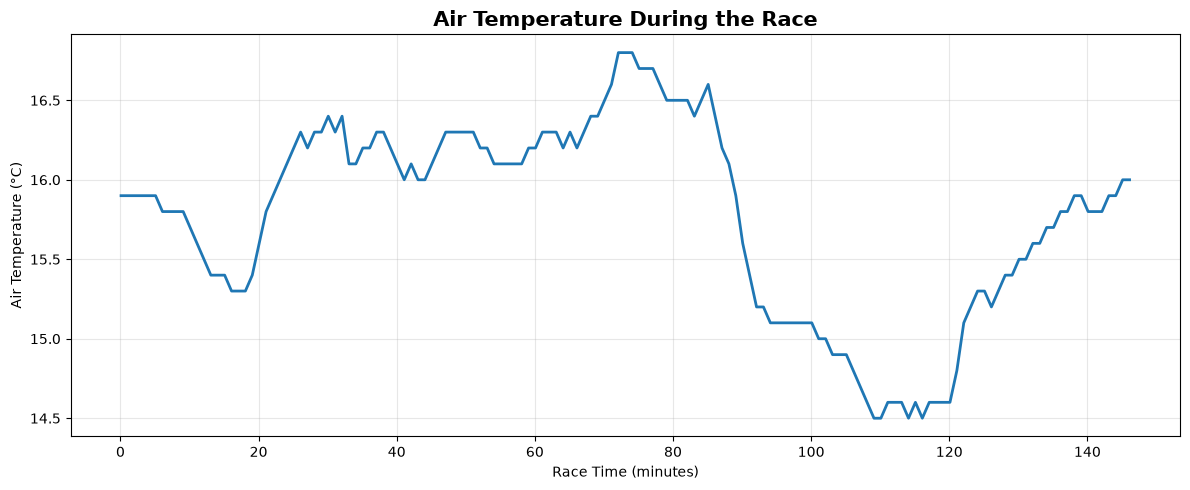

In [8]:
plt.figure(figsize=(12,5))

plt.plot(
    weather["Time"].dt.total_seconds()/60,
    weather["AirTemp"],
    linewidth=2
)

plt.title(
    "Air Temperature During the Race",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Race Time (minutes)")
plt.ylabel("Air Temperature (°C)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../docs/phase_01/screenshots/weather_air_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Air temperature remained relatively stable throughout the race.
- This provides environmental context but does not directly explain lap-time differences.

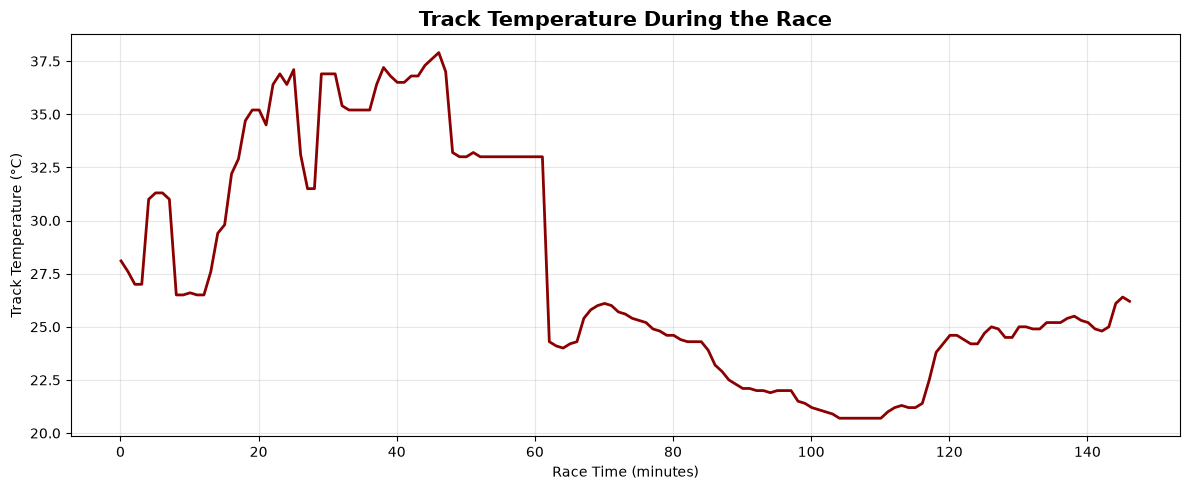

In [9]:
plt.figure(figsize=(12,5))

plt.plot(
    weather["Time"].dt.total_seconds()/60,
    weather["TrackTemp"],
    linewidth=2,
    color="darkred"
)

plt.title(
    "Track Temperature During the Race",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Race Time (minutes)")
plt.ylabel("Track Temperature (°C)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../docs/phase_01/screenshots/weather_track_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

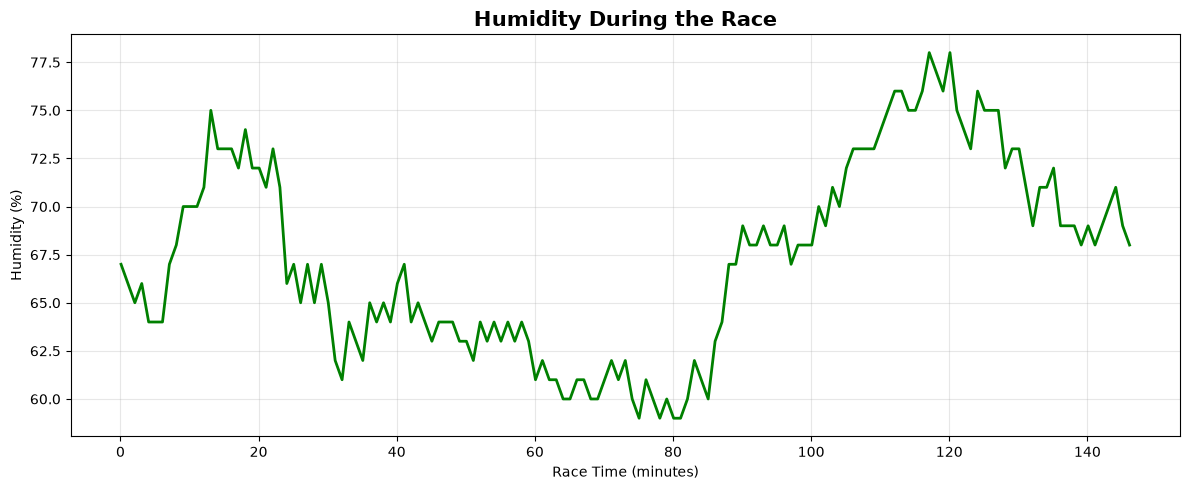

In [10]:
plt.figure(figsize=(12,5))

plt.plot(
    weather["Time"].dt.total_seconds()/60,
    weather["Humidity"],
    linewidth=2,
    color="green"
)

plt.title(
    "Humidity During the Race",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Race Time (minutes)")
plt.ylabel("Humidity (%)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../docs/phase_01/screenshots/weather_humidity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

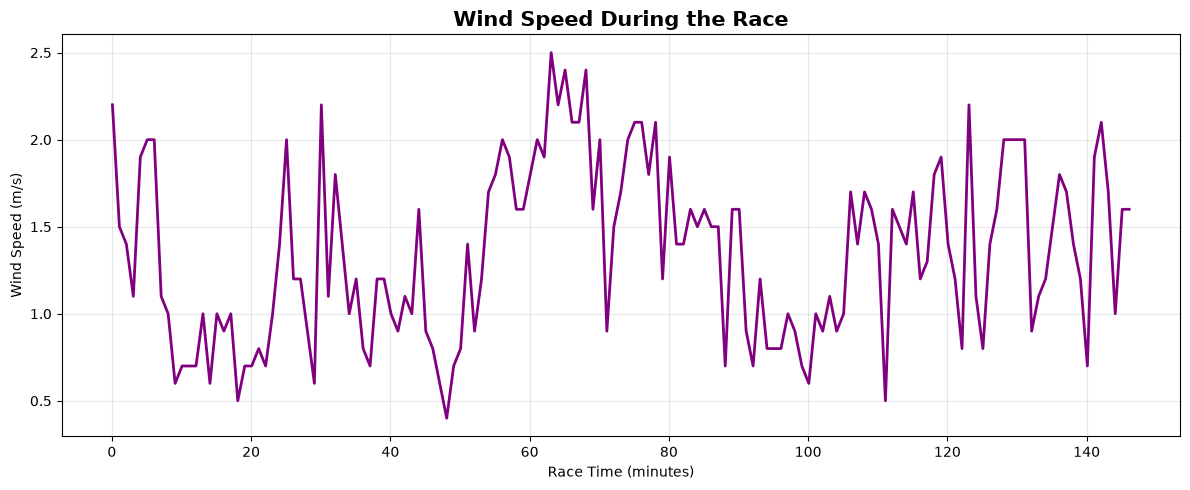

In [11]:
plt.figure(figsize=(12,5))

plt.plot(
    weather["Time"].dt.total_seconds()/60,
    weather["WindSpeed"],
    linewidth=2,
    color="purple"
)

plt.title(
    "Wind Speed During the Race",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Race Time (minutes)")
plt.ylabel("Wind Speed (m/s)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../docs/phase_01/screenshots/weather_wind_speed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
weather["Rainfall"].value_counts()

Rainfall
False    96
True     51
Name: count, dtype: int64